## 1. Imports & Setup
Imports required libraries: PyTorch for modelling, NumPy and Pandas for data handling, Matplotlib for visualization, and scikit-learn for scaling.

In [1]:
import math
import copy
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
import random

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG — edit here, run once, then execute the rest of the notebook
# ══════════════════════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 55

# ── Target ────────────────────────────────────────────────────────────────────
# Options: 'price day ahead', 'price actual', 'total load actual',
#          'gen_solar', 'gen_wind'
TARGET = 'price actual'

# ── Feature engineering toggles ───────────────────────────────────────────────
ADD_FORECAST   = True   # shift(−FORECAST_SHIFT) day-ahead load/solar/wind forecasts
FORECAST_SHIFT = 1     # ← change to 24 for day-ahead, 1 for next-hour
ADD_LAGS       = True   # target lag features
LAG_HOURS      = [1, 2, 3, 24, 48]  # which lags to include when ADD_LAGS=True


# ── Sequence config ───────────────────────────────────────────────────────────
WINDOW_SIZE = 24   # hours of look-back context
HORIZON     = 1   # hours ahead to forecast

# ── Transformer architecture ──────────────────────────────────────────────────
D_MODEL         = 64    # embedding dim — must be divisible by N_HEAD
N_HEAD          = 4
NUM_ENC_LAYERS  = 2
DIM_FEEDFORWARD = 256
DROPOUT         = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
num_epochs    = 50
learning_rate = 1e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 1.0     # max_norm for gradient clipping

# ── LR scheduler ─────────────────────────────────────────────────────────────
LR_PATIENCE = 10   # epochs without improvement before halving LR
LR_FACTOR   = 0.5

# ── Loss function ─────────────────────────────────────────────────────────────
# Options: 'mae', 'mse', 'custom'
LOSS_FN     = 'mse'
CUSTOM_ALPHA = 0.1   # weight on JSD term (only used when LOSS_FN='custom')
CUSTOM_BETA  = 0.01  # weight on smoothness term

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = 4   if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()


### Manual seed 

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Random seed set to {SEED}")

Random seed set to 55


## 2. Data Loading
Loads the merged energy and weather dataset (35,064 rows x 62 columns) - hourly observations with energy production/consumption and weather features.

In [4]:
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather.info()
print(f"\nShape: {energy_weather.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  object 
 1   date                             35064 non-null  object 
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro  

## 3. Feature & Target Definition
Set `TARGET` to whichever column you want to predict. Then toggle features on/off by commenting or uncommenting lines in `feature_cols` — the target is automatically excluded. Columns are grouped by category to make it easy to swap between simple and full setups.

In [5]:
# ── Features ─────────────────────────────────────────────────────────────────
# Comment out any column you don't want as an input feature.
# TARGET is automatically removed from this list at the bottom.

feature_cols = [

    # ── Forecasts (day-ahead signals published before the target hour) ────────
    # 'forecast solar day ahead',
    # 'forecast wind onshore day ahead',
    # 'total load forecast',

    # ── Grid & generation ─────────────────────────────────────────────────────
    'total load actual',
    'gen_solar',
    'gen_wind',
    'gen_hydro',
    'gen_pumped_hydro',
    'gen_fossil',
    'gen_nuclear',
    'gen_other',

    # ── Other price series ────────────────────────────────────────────────────
    # 'price actual',
    # 'price day ahead', 

    # ── Weather — temperature (per city) ─────────────────────────────────────
    # 'temp_Barcelona',
    # 'temp_Bilbao',
    # 'temp_Madrid',
    # 'temp_Seville',
    # 'temp_Valencia',
    # 'temp_avg',                   # average across cities — redundant with above

    # ── Weather — wind speed (per city) ──────────────────────────────────────
    # 'wind_speed_Barcelona',
    # 'wind_speed_Bilbao',
    # 'wind_speed_Madrid',
    # 'wind_speed_Seville',
    # 'wind_speed_Valencia',

    # ── Weather — cloud cover (per city) ─────────────────────────────────────
    # 'clouds_all_Barcelona',
    # 'clouds_all_Bilbao',
    # 'clouds_all_Madrid',
    # 'clouds_all_Seville',
    # 'clouds_all_Valencia',

    # ── Weather — rain 3h (per city) ─────────────────────────────────────────
    # 'rain_3h_Barcelona',
    # 'rain_3h_Bilbao',
    # 'rain_3h_Madrid',
    # 'rain_3h_Seville',
    # 'rain_3h_Valencia',

    # ── Weather — rain 1h (per city) — often sparse, consider removing ────────
    # 'rain_1h_Barcelona',
    # 'rain_1h_Bilbao',
    # 'rain_1h_Madrid',
    # 'rain_1h_Seville',
    # 'rain_1h_Valencia',

    # ── Weather — snow 3h (per city) — mostly zero outside winter ────────────
    # 'snow_3h_Barcelona',
    # 'snow_3h_Bilbao',
    # 'snow_3h_Madrid',
    # 'snow_3h_Seville',
    # 'snow_3h_Valencia',

    # ── Weather — wind direction (per city) — circular, consider encoding ─────
    # 'wind_deg_Barcelona',
    # 'wind_deg_Bilbao',
    # 'wind_deg_Madrid',
    # 'wind_deg_Seville',
    # 'wind_deg_Valencia',

    # ── Weather — humidity (per city) ────────────────────────────────────────
    # 'humidity_Barcelona',
    # 'humidity_Bilbao',
    # 'humidity_Madrid',
    # 'humidity_Seville',
    # 'humidity_Valencia',

    # ── Weather — pressure (per city) ────────────────────────────────────────
    # 'pressure_Barcelona',
    # 'pressure_Bilbao',
    # 'pressure_Madrid',
    # 'pressure_Seville',
    # 'pressure_Valencia',
]

# Remove TARGET from features if it appears in the list above
feature_cols = [c for c in feature_cols if c != TARGET]

print(f"Target   : {TARGET}")
print(f"Features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Target   : price actual
Features (8):
  total load actual
  gen_solar
  gen_wind
  gen_hydro
  gen_pumped_hydro
  gen_fossil
  gen_nuclear
  gen_other


## 4. Feature Engineering
Adds cyclical encodings of hour-of-day, day-of-week, and month (sine/cosine pairs) so the model can learn daily and weekly price patterns, plus a binary weekend flag. No lag features are created.

In [6]:
energy_weather['time'] = pd.to_datetime(energy_weather['time'])
energy_weather['year'] = energy_weather['time'].dt.year

# UTC timestamps include one row from 2014-12-31 23:00 UTC
# (= first hour of 2015 in Central European Time). Drop it so
# the year column contains only complete calendar years 2015-2018.
energy_weather = energy_weather[energy_weather['year'] >= 2015].reset_index(drop=True)

hour  = energy_weather['time'].dt.hour
dow   = energy_weather['time'].dt.dayofweek
month = energy_weather['time'].dt.month

energy_weather['hour_sin']   = np.sin(2 * np.pi * hour        / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * hour        / 24)
energy_weather['day_sin']    = np.sin(2 * np.pi * dow         / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * dow         / 7)
energy_weather['month_sin']  = np.sin(2 * np.pi * (month - 1) / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * (month - 1) / 12)
energy_weather['is_weekend'] = (dow >= 5).astype(float)

time_features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'month_sin', 'month_cos', 'is_weekend',
]
feature_cols = feature_cols + time_features


In [7]:
# ── Forward-looking forecast features (optional) ──────────────────────────────

if ADD_FORECAST:
    energy_weather['total_load_forecast_ahead'] = \
        energy_weather['total load forecast'].shift(-FORECAST_SHIFT)
    
    energy_weather['forecast_solar_ahead'] = \
        energy_weather['forecast solar day ahead'].shift(-FORECAST_SHIFT)
    
    energy_weather['forecast_wind_ahead'] = \
        energy_weather['forecast wind onshore day ahead'].shift(-FORECAST_SHIFT)
    
    forecast_cols = [
        'total_load_forecast_ahead',
        'forecast_solar_ahead',
        'forecast_wind_ahead'
    ]
    feature_cols = feature_cols + forecast_cols
    
    print(f"Forward forecast features added : {forecast_cols}")
    print(f"Forecast shift                  : {FORECAST_SHIFT} hour(s) ahead")
    print(f"Total features now              : {len(feature_cols)}")
else:
    forecast_cols = []
    print("Forward forecast features: disabled")

Forward forecast features added : ['total_load_forecast_ahead', 'forecast_solar_ahead', 'forecast_wind_ahead']
Forecast shift                  : 1 hour(s) ahead
Total features now              : 18


In [8]:
# ── 3. Lag features ───────────────────────────────────────────────────────────

if ADD_LAGS:
    lag_hours = LAG_HOURS
    lag_cols  = []
    for lag in lag_hours:
        col_name = f"{TARGET.replace(' ', '_')}_lag_{lag}"
        energy_weather[col_name] = energy_weather[TARGET].shift(lag)
        lag_cols.append(col_name)
    feature_cols = feature_cols + lag_cols
    print(f"Lag features added  : {len(lag_cols)}")
    print(f"Total features now  : {len(feature_cols)}")
else:
    lag_cols = []
    print("Lag features: disabled")

# ── 4. Single dropna — covers everything ─────────────────────────────────────
energy_weather = energy_weather.dropna(
    subset=feature_cols + [TARGET]
).reset_index(drop=True)

print(f"Shape after feature engineering : {energy_weather.shape}")
print(f"Total input features            : {len(feature_cols)}")
print(f"Years in data                   : {sorted(energy_weather['year'].unique())}")

Lag features added  : 5
Total features now  : 23
Shape after feature engineering : (35014, 78)
Total input features            : 23
Years in data                   : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [9]:
feature_cols

['total load actual',
 'gen_solar',
 'gen_wind',
 'gen_hydro',
 'gen_pumped_hydro',
 'gen_fossil',
 'gen_nuclear',
 'gen_other',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 'total_load_forecast_ahead',
 'forecast_solar_ahead',
 'forecast_wind_ahead',
 'price_actual_lag_1',
 'price_actual_lag_2',
 'price_actual_lag_3',
 'price_actual_lag_24',
 'price_actual_lag_48']

## 5. Train / Validation / Test Split
Splits by calendar year in strict chronological order: **first 2 years -> train, year 3 -> validation, year 4 -> test**. `MinMaxScaler` is fit only on the training set to prevent data leakage. The target has its own scaler so predictions can be inverse-transformed back to EUR/MWh.

In [10]:
years = sorted(energy_weather['year'].unique())

train_df = energy_weather[energy_weather['year'].isin(years[:2])].reset_index(drop=True)
val_df   = energy_weather[energy_weather['year'] == years[2]].reset_index(drop=True)
test_df  = energy_weather[energy_weather['year'] == years[3]].reset_index(drop=True)

# ── Split feature_cols into two groups ───────────────────────────────────────
no_scale_features = time_features                                        # already in [-1, 1]
scale_features    = [c for c in feature_cols if c not in no_scale_features]  # everything else

# Features — fit scaler on train only, applied to scale_features only
feat_scaler = MinMaxScaler()

def scale_features_df(df):
    scaled_part    = feat_scaler.transform(df[scale_features].values)
    noscale_part   = df[no_scale_features].values
    return np.concatenate([scaled_part, noscale_part], axis=1)

feat_scaler.fit(train_df[scale_features].values)

X_train = scale_features_df(train_df)
X_val   = scale_features_df(val_df)
X_test  = scale_features_df(test_df)

# Target — fit on train only
tgt_scaler = MinMaxScaler()
y_train = tgt_scaler.fit_transform(train_df[[TARGET]].values).ravel()
y_val   = tgt_scaler.transform(val_df[[TARGET]].values).ravel()
y_test  = tgt_scaler.transform(test_df[[TARGET]].values).ravel()

print(f"Train : {years[:2]}  ->  {len(train_df):,} rows")
print(f"Val   : {years[2]}   ->  {len(val_df):,} rows")
print(f"Test  : {years[3]}   ->  {len(test_df):,} rows")
print(f"Features scaled    : {len(scale_features)}")
print(f"Features not scaled: {len(no_scale_features)} (sin/cos + is_weekend)")


Train : [np.int32(2015), np.int32(2016)]  ->  17,496 rows
Val   : 2017   ->  8,760 rows
Test  : 2018   ->  8,758 rows
Features scaled    : 16
Features not scaled: 7 (sin/cos + is_weekend)


### Check the distribution of the target variable for skewness/outliers 

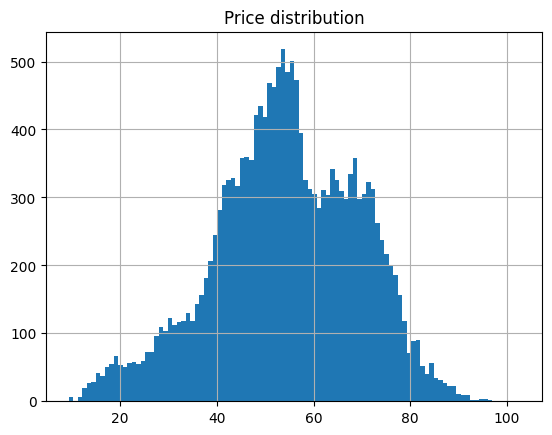

count    17496.000000
mean        54.358391
std         15.001335
min          9.330000
25%         44.860000
50%         54.290000
75%         65.672500
max        102.620000
Name: price actual, dtype: float64
Skew: -0.25


In [11]:
import matplotlib.pyplot as plt
train_df[TARGET].hist(bins=100)
plt.title('Price distribution')
plt.show()

print(train_df[TARGET].describe())
print(f"Skew: {train_df[TARGET].skew():.2f}")

## 6. Split Verification
Confirms array shapes and date ranges for each split.

In [12]:
print(f"X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}      y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}     y_test  : {y_test.shape}")

print(f"\nTrain : {train_df['time'].iloc[0]}  ->  {train_df['time'].iloc[-1]}")
print(f"Val   : {val_df['time'].iloc[0]}  ->  {val_df['time'].iloc[-1]}")
print(f"Test  : {test_df['time'].iloc[0]}  ->  {test_df['time'].iloc[-1]}")

print(f"\nFeature scale check -- X_train : min={X_train.min():.3f}, max={X_train.max():.3f}")
print(f"Target  scale check -- y_train : min={y_train.min():.3f}, max={y_train.max():.3f}")

X_train : (17496, 23)    y_train : (17496,)
X_val   : (8760, 23)      y_val   : (8760,)
X_test  : (8758, 23)     y_test  : (8758,)

Train : 2015-01-03 00:00:00+00:00  ->  2016-12-31 23:00:00+00:00
Val   : 2017-01-01 00:00:00+00:00  ->  2017-12-31 23:00:00+00:00
Test  : 2018-01-01 00:00:00+00:00  ->  2018-12-31 21:00:00+00:00

Feature scale check -- X_train : min=-1.000, max=1.000
Target  scale check -- y_train : min=0.000, max=1.000


## 7. Configuration
Hyperparameters for the data pipeline and Transformer model.

| Parameter | Value | Notes |
|---|---|---|
| `WINDOW_SIZE` | 24 | Hours of look-back the Transformer attends over |
| `HORIZON` | 1 | Hours ahead to forecast |
| `D_MODEL` | 64 | Internal embedding dimension (must be divisible by `N_HEAD`) |
| `N_HEAD` | 4 | Self-attention heads |
| `NUM_ENC_LAYERS` | 2 | Stacked encoder blocks |
| `DIM_FEEDFORWARD` | 256 | FFN hidden dimension inside each encoder block |
| `DROPOUT` | 0.1 | Applied after attention and FFN sub-layers |

In [13]:
INPUT_SIZE      = len(feature_cols) 

print(f"Input window     : {WINDOW_SIZE} hours")
print(f"Forecast horizon : {HORIZON} hours")
print(f"Input features   : {INPUT_SIZE}")
print(f"d_model={D_MODEL}, heads={N_HEAD}, enc_layers={NUM_ENC_LAYERS}, ffn={DIM_FEEDFORWARD}")

Input window     : 24 hours
Forecast horizon : 1 hours
Input features   : 23
d_model=64, heads=4, enc_layers=2, ffn=256


## 8. Dataset & DataLoader Construction
`EnergyDataset` slices the data into overlapping windows. For each index the input is the past `WINDOW_SIZE` hours of features and the target is the next `HORIZON` hours of day-ahead price.

In [14]:
class EnergyDataset(Dataset):
    def __init__(self, X, y, window_size=WINDOW_SIZE, horizon=HORIZON):
        self.X           = torch.tensor(X, dtype=torch.float32)
        self.y           = torch.tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon     = horizon

    def __len__(self):
        return len(self.X) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_seq = self.y[idx + self.window_size : idx + self.window_size + self.horizon]
        return x_seq, y_seq

In [15]:
train_dataset = EnergyDataset(X_train, y_train)
val_dataset   = EnergyDataset(X_val,   y_val)
test_dataset  = EnergyDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

x_sample, y_sample = next(iter(train_loader))
print(f"X batch : {tuple(x_sample.shape)}  ->  expected (batch, {WINDOW_SIZE}, {INPUT_SIZE})")
print(f"y batch : {tuple(y_sample.shape)}  ->  expected (batch, {HORIZON})")

X batch : (256, 24, 23)  ->  expected (batch, 24, 23)
y batch : (256, 1)  ->  expected (batch, 1)


## 9. Model Architecture

A standard Transformer **encoder-only** pipeline:

1. **Input projection** - linear layer maps each timestep from `INPUT_SIZE` raw features to `D_MODEL` dimensions.
2. **Positional encoding** - adds sinusoidal position signals so the model knows the order of timesteps (Transformers have no built-in sense of sequence order).
3. **Transformer encoder** - `NUM_ENC_LAYERS` stacked encoder blocks, each containing:
   - Multi-head self-attention (`N_HEAD` heads, each of size `D_MODEL // N_HEAD`)
   - Feed-forward network (`DIM_FEEDFORWARD` hidden units)
   - Layer norm + residual connections (built into PyTorch's `TransformerEncoderLayer`)
4. **Output head** - takes the **last timestep's** representation and projects it to `HORIZON` output values via a single linear layer.

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EnergyTransformer(nn.Module):
    def __init__(self, input_size, d_model=D_MODEL, nhead=N_HEAD,
                 num_encoder_layers=NUM_ENC_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD,
                 dropout=DROPOUT, horizon=HORIZON):
        super().__init__()
        self.input_proj   = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_head  = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, window_size, input_size)
        x = self.input_proj(x)        # -> (batch, window_size, d_model)
        x = self.pos_encoding(x)      # -> (batch, window_size, d_model)
        x = self.transformer(x)       # -> (batch, window_size, d_model)
        x = x[:, -1, :]              # last timestep -> (batch, d_model)
        return self.output_head(x)    # -> (batch, horizon)

In [17]:
_model = EnergyTransformer(input_size=INPUT_SIZE)
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"EnergyTransformer -- {total_params:,} trainable parameters")
print(_model)

EnergyTransformer -- 101,569 trainable parameters
EnergyTransformer(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=64, out_features

## 10. Device Selection
Selects the best available compute device: CUDA (NVIDIA GPU) -> MPS (Apple Silicon) -> CPU.

In [18]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A4000


## 11. Training & Evaluation Functions
`train_model()` uses **MSE loss** for training (smoother gradients than MAE), an Adam optimizer, and a `ReduceLROnPlateau` scheduler that halves the learning rate after 5 epochs without improvement. `test_model()` evaluates on the test set and inverse-transforms predictions back to original price units (EUR/MWh), reporting **MAE** and **RMSE** as the final metrics.

### Custom Loss Function 

In [19]:
import copy

# ── Custom Loss ───────────────────────────────────────────────────────────────
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ──────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ──────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ────────────────────────────────────
        smoothness = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness

### Training loop 

In [20]:
def train_model(model, train_loader, val_loader,
                num_epochs=50, lr=1e-3, device='cpu',
                print_every=1, loss_fn='mae',
                weight_decay=1e-4, alpha=0.1, beta=0.01):

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

    # ── Loss selection ────────────────────────────────────────────────────────
    if loss_fn == 'mae':
        criterion  = nn.L1Loss()
        loss_label = 'MAE'
    elif loss_fn == 'mse':
        criterion  = nn.MSELoss()
        loss_label = 'MSE'
    elif loss_fn == 'custom':
        criterion  = CustomLoss(alpha=alpha, beta=beta)
        loss_label = f'Custom (α={alpha} β={beta})'
    else:
        raise ValueError(f"loss_fn must be 'mae', 'mse' or 'custom', got '{loss_fn}'")

    print(f"Training with {loss_label} loss")

    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_weights)
    print(f"\nBest val loss ({loss_label}): {best_val_loss:.4f}")
    return model, history


## 12. Training Execution
Trains the Transformer on the 2-year training set, monitors on the validation year, then evaluates on the held-out test year.

In [21]:
import time

assert X_train.shape[1] == INPUT_SIZE, (
    f"Feature mismatch: X_train has {X_train.shape[1]} features but "
    f"INPUT_SIZE={INPUT_SIZE}. Re-run cells 6 → 8 → 13 → 17 before training."
)

model = EnergyTransformer(input_size=INPUT_SIZE).to(device)

t0 = time.time()
trained_model, history = train_model(
    model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, device=device, loss_fn=LOSS_FN, weight_decay=WEIGHT_DECAY
)

elapsed = time.time() - t0

mins, secs = divmod(int(elapsed), 60)
print(f"\nTotal training time: {mins}m {secs}s")

Training with MSE loss
Epoch   1/50  train=0.0632  val=0.0069  lr=1.00e-04
Epoch   2/50  train=0.0203  val=0.0052  lr=1.00e-04
Epoch   3/50  train=0.0143  val=0.0049  lr=1.00e-04
Epoch   4/50  train=0.0112  val=0.0043  lr=1.00e-04
Epoch   5/50  train=0.0096  val=0.0041  lr=1.00e-04
Epoch   6/50  train=0.0087  val=0.0039  lr=1.00e-04
Epoch   7/50  train=0.0078  val=0.0038  lr=1.00e-04
Epoch   8/50  train=0.0074  val=0.0037  lr=1.00e-04
Epoch   9/50  train=0.0070  val=0.0034  lr=1.00e-04
Epoch  10/50  train=0.0066  val=0.0034  lr=1.00e-04
Epoch  11/50  train=0.0062  val=0.0031  lr=1.00e-04
Epoch  12/50  train=0.0060  val=0.0034  lr=1.00e-04
Epoch  13/50  train=0.0057  val=0.0032  lr=1.00e-04
Epoch  14/50  train=0.0056  val=0.0031  lr=1.00e-04
Epoch  15/50  train=0.0053  val=0.0029  lr=1.00e-04
Epoch  16/50  train=0.0052  val=0.0028  lr=1.00e-04
Epoch  17/50  train=0.0051  val=0.0028  lr=1.00e-04
Epoch  18/50  train=0.0050  val=0.0028  lr=1.00e-04
Epoch  19/50  train=0.0048  val=0.0027  l

## 13. Testing & Evaluation 

### Helper functions for testing/evaluation 

In [22]:
def compute_metrics(preds_orig, actuals_orig):
    mae  = float(np.mean(np.abs(preds_orig - actuals_orig)))
    rmse = float(np.sqrt(np.mean((preds_orig - actuals_orig) ** 2)))
    mape = float(np.mean(np.abs((actuals_orig - preds_orig) /
                                 np.abs(actuals_orig).clip(min=1.0))) * 100)
    mae_per_horizon = np.mean(np.abs(preds_orig - actuals_orig), axis=0)
    return mae, rmse, mape, mae_per_horizon


def print_metrics(mae, rmse, mape, mae_per_horizon):
    print(f"MAE  : {mae:.3f} EUR/MWh  (on average, predictions are off by {mae:.1f} EUR/MWh)")
    print(f"RMSE : {rmse:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
    print(f"MAPE : {mape:.2f}%          (on average, predictions are off by {mape:.1f}% of the actual price)")

### Test using the best model (i.e the one with the lowest validation loss)

In [23]:
def test_model(model, test_loader, tgt_scaler, device='cpu'):
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch.to(device)).cpu().numpy()
            all_preds.append(preds)
            all_actuals.append(y_batch.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # (N, 1)
    actuals = np.concatenate(all_actuals, axis=0)   # (N, 1)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print("── Overlapping Evaluation ──")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,
        'actuals'         : actuals_orig,
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        # 'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

In [24]:
results = test_model(trained_model, test_loader, tgt_scaler, device=device)

── Overlapping Evaluation ──
MAE  : 3.435 EUR/MWh  (on average, predictions are off by 3.4 EUR/MWh)
RMSE : 4.518 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 6.21%          (on average, predictions are off by 6.2% of the actual price)


## 14. Visualization 
Visualizing 1 hour `actual price` prediction results  

In [25]:
def plot_results(results, history, plot_days=30):
    preds   = results['preds']
    actuals = results['actuals']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Actual Price Forecast -- Transformer (1h ahead)',
                 fontsize=14, fontweight='bold')

    # ── Top left: First N days ────────────────────────────────────────────────
    ax          = axes[0, 0]
    n_hours     = plot_days * 24
    n           = min(n_hours, len(preds.ravel()))
    actual_days = n // 24
    ax.plot(actuals.ravel()[:n], label='Actual',    alpha=0.8, linewidth=0.8)
    ax.plot(preds.ravel()[:n],   label='Predicted', alpha=0.8, linewidth=0.8)
    ax.set_title(f'First {actual_days} days of test period')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # ── Top right: Sample 48h window (replaces single horizon plot) ───────────
    ax      = axes[0, 1]
    idx     = 200
    window  = 48   # show 48 hours around idx
    start   = max(0, idx)
    end     = min(start + window, len(preds.ravel()))
    ax.plot(actuals.ravel()[start:end], marker='o', markersize=3,
            label='Actual',    linewidth=1.2)
    ax.plot(preds.ravel()[start:end],   marker='x', markersize=3,
            label='Predicted', linewidth=1.2)
    ax.set_title(f'Sample 48h window (hours {start}-{end})')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # ── Bottom left: Residual distribution ───────────────────────────────────
    ax     = axes[1, 0]
    errors = (preds - actuals).ravel()
    ax.hist(errors, bins=60, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
               label='Zero error (perfect)')
    ax.axvline(results['mae'],  color='orange', linestyle='--', linewidth=1.2,
               label=f'MAE = ±{results["mae"]:.2f} EUR/MWh')
    ax.axvline(-results['mae'], color='orange', linestyle='--', linewidth=1.2)
    ax.set_title('Residual distribution')
    ax.set_xlabel('Error (EUR/MWh)')
    ax.set_ylabel('Count')
    ax.legend()

    # ── Bottom right: Training history ───────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(history['train_loss'], label=f'Train ({LOSS_FN.upper()})')
    ax.plot(history['val_loss'],   label=f'Val ({LOSS_FN.upper()})')
    ax.set_title(f'Training history  |  loss={LOSS_FN.upper()}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'{LOSS_FN.upper()} loss (scaled)')
    ax.legend()

    plt.tight_layout()
    plt.show()

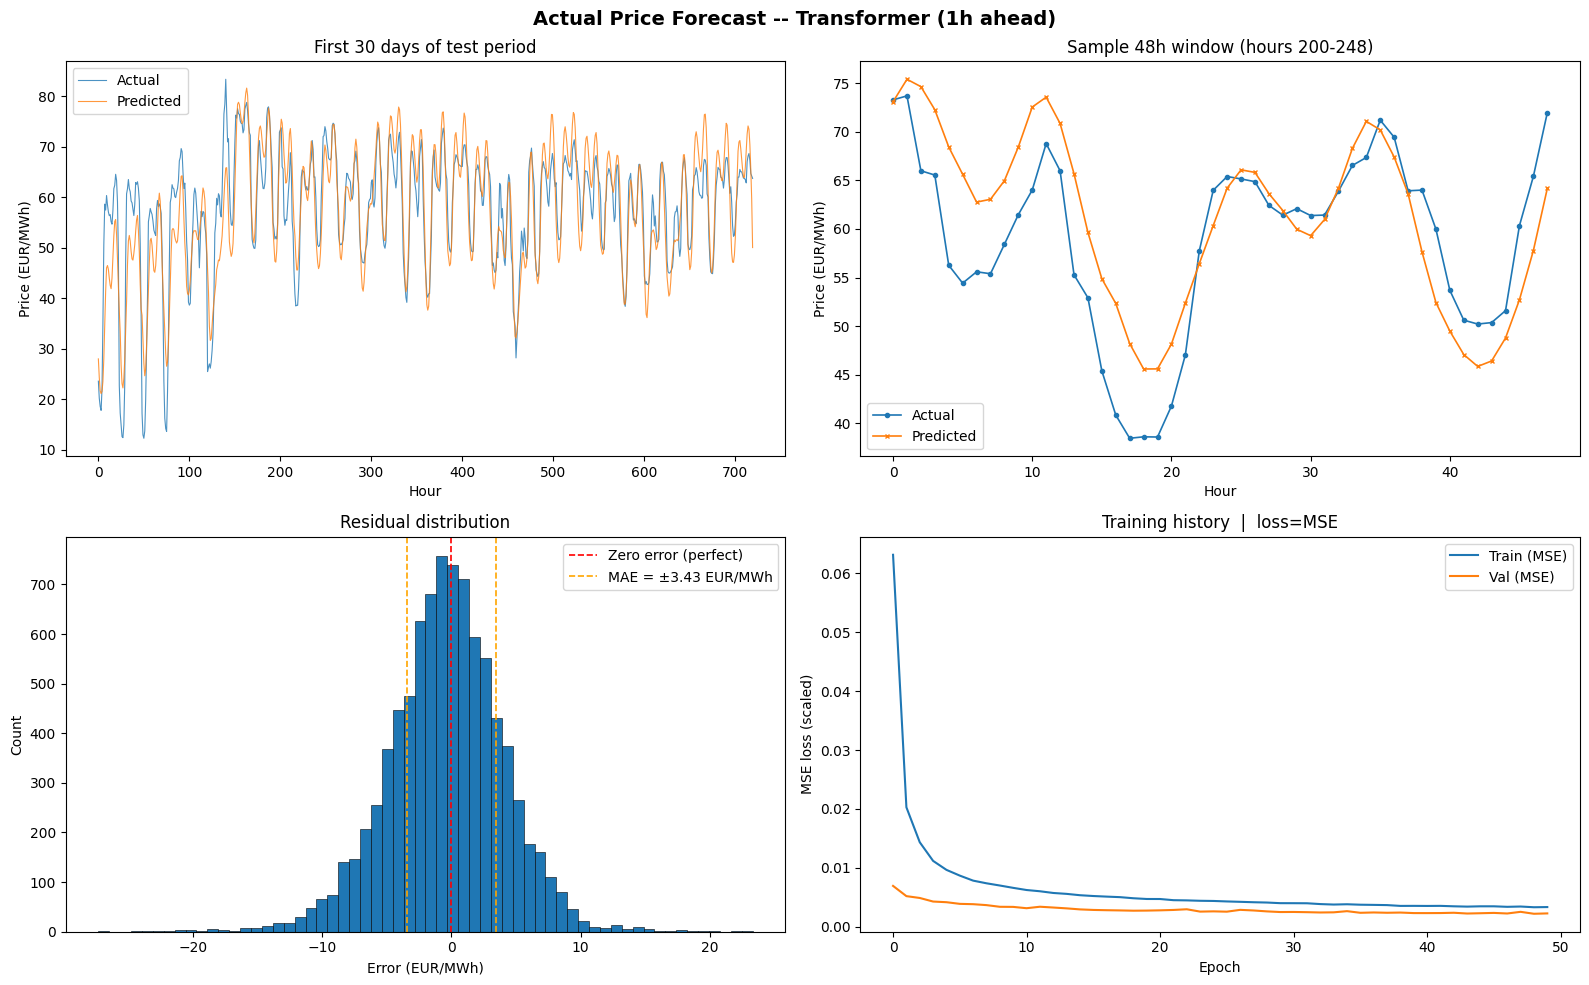

In [26]:
plot_results(results, history, plot_days=30)

### Results by Season 

In [27]:
def evaluate_by_season(results, test_df, stride=1):
    preds   = results['preds']
    actuals = results['actuals']
    n       = len(preds)

    times = pd.to_datetime(test_df['time'].values)

    # generate start indices based on stride
    starts = list(range(WINDOW_SIZE,
                        WINDOW_SIZE + n * stride,
                        stride))[:n]
    times  = times[starts]

    month  = pd.Series(times).dt.month

    seasons = {
        'Winter' : month.isin([12, 1, 2]),
        'Spring' : month.isin([3, 4, 5]),
        'Summer' : month.isin([6, 7, 8]),
        'Autumn' : month.isin([9, 10, 11]),
    }

    print(f"\n── Seasonal Error Breakdown (stride={stride}) ───────────────")
    print(f"{'Season':<10} {'N':>6} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
    print(f"{'─'*44}")

    season_results = {}
    for season, mask in seasons.items():
        s_preds   = preds[mask.values].ravel()
        s_actuals = actuals[mask.values].ravel()

        mae  = float(np.mean(np.abs(s_preds - s_actuals)))
        rmse = float(np.sqrt(np.mean((s_preds - s_actuals) ** 2)))
        mape = float(np.mean(np.abs((s_actuals - s_preds) /
                                     np.abs(s_actuals).clip(min=1.0))) * 100)

        print(f"{season:<10} {mask.sum():>6,} {mae:>8.3f} {rmse:>8.3f} {mape:>7.2f}%")

        season_results[season] = {
            'mae' : mae,
            'rmse': rmse,
            'mape': mape,
            'n'   : int(mask.sum())
        }

    print(f"{'─'*44}")
    print(f"{'Overall':<10} {n:>6,} "
          f"{results['mae']:>8.3f} "
          f"{results['rmse']:>8.3f} "
          f"{results['mape']:>7.2f}%")

    return season_results



def plot_seasonal(season_results):
    seasons = list(season_results.keys())
    maes    = [season_results[s]['mae']  for s in seasons]
    rmses   = [season_results[s]['rmse'] for s in seasons]
    mapes   = [season_results[s]['mape'] for s in seasons]

    x = np.arange(len(seasons))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Forecast Error by Season — 2018 Test Set',
                 fontsize=13, fontweight='bold')

    for ax, values, label, color in zip(
        axes,
        [maes, rmses, mapes],
        ['MAE (EUR/MWh)', 'RMSE (EUR/MWh)', 'MAPE (%)'],
        ['steelblue', 'darkorange', 'seagreen']
    ):
        bars = ax.bar(x, values, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(seasons)
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(axis='y', alpha=0.3)

        # value labels on bars
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [28]:
# overlapping
season_results = evaluate_by_season(results, test_df, stride=1)


── Seasonal Error Breakdown (stride=1) ───────────────
Season          N      MAE     RMSE     MAPE
────────────────────────────────────────────
Winter      2,134    3.716    4.820    6.65%
Spring      2,208    4.239    5.497    9.70%
Summer      2,208    2.552    3.321    3.83%
Autumn      2,184    3.239    4.151    4.67%
────────────────────────────────────────────
Overall     8,734    3.435    4.518    6.21%


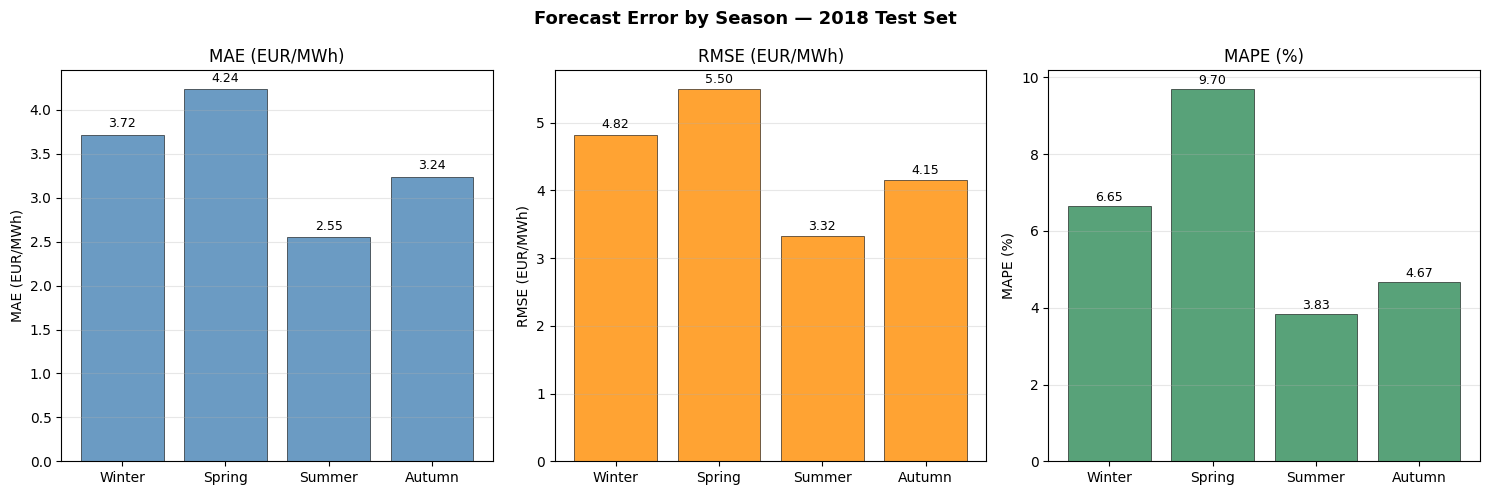

In [29]:
plot_seasonal(season_results)

### Main Outputs 

In [30]:
mins, secs = divmod(int(elapsed), 60)
if device.type == 'cuda':
    device_label = f"cuda ({torch.cuda.get_device_name(0)})"
elif device.type == 'mps':
    device_label = "mps (Apple Silicon)"
else:
    device_label = "cpu"

print(f"\nTotal training time: {mins}m {secs}s  |  device: {device_label}")


Total training time: 1m 37s  |  device: cuda (NVIDIA RTX A4000)


In [31]:
print(f"MAE  : {results['mae']:.3f} EUR/MWh  (on average, predictions are off by {results['mae']:.1f} EUR/MWh)")
print(f"RMSE : {results['rmse']:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
print(f"MAPE : {results['mape']:.2f}%          (on average, predictions are off by {results['mape']:.1f}% of the actual price)")

MAE  : 3.435 EUR/MWh  (on average, predictions are off by 3.4 EUR/MWh)
RMSE : 4.518 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 6.21%          (on average, predictions are off by 6.2% of the actual price)


### Price (day-ahead; actual) / Load by season [Descriptive Plots] 

In [32]:
test_df_filtered = test_df.copy()[['time', 'date', 'hour', 
                                   'total load actual', 'gen_solar', 'gen_wind', 
                                   'price day ahead', 'price actual']]

In [33]:
test_df.columns

Index(['time', 'date', 'hour', 'forecast solar day ahead',
       'forecast wind onshore day ahead', 'total load forecast',
       'total load actual', 'price day ahead', 'price actual', 'gen_solar',
       'gen_wind', 'gen_hydro', 'gen_pumped_hydro', 'gen_fossil',
       'gen_nuclear', 'gen_other', 'temp_Barcelona', 'temp_Bilbao',
       'temp_Madrid', 'temp_Seville', 'temp_Valencia', 'pressure_Barcelona',
       'pressure_Bilbao', 'pressure_Madrid', 'pressure_Seville',
       'pressure_Valencia', 'humidity_Barcelona', 'humidity_Bilbao',
       'humidity_Madrid', 'humidity_Seville', 'humidity_Valencia',
       'wind_speed_Barcelona', 'wind_speed_Bilbao', 'wind_speed_Madrid',
       'wind_speed_Seville', 'wind_speed_Valencia', 'wind_deg_Barcelona',
       'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Seville',
       'wind_deg_Valencia', 'rain_1h_Barcelona', 'rain_1h_Bilbao',
       'rain_1h_Madrid', 'rain_1h_Seville', 'rain_1h_Valencia',
       'rain_3h_Barcelona', 'rain_3h_Bilbao',

In [34]:
test_df_filtered

,time,date,hour,total load actual,gen_solar,gen_wind,price day ahead,price actual
0,2018-01-01 00:00:00+00:00,2018-01-01,0,22009.0,9.0,11156.0,4.74,19.02
1,2018-01-01 01:00:00+00:00,2018-01-01,1,20589.0,9.0,9437.0,3.66,17.90
2,2018-01-01 02:00:00+00:00,2018-01-01,2,19547.0,9.0,6474.0,2.30,20.88
3,2018-01-01 03:00:00+00:00,2018-01-01,3,18871.0,9.0,6329.0,2.30,18.83
4,2018-01-01 04:00:00+00:00,2018-01-01,4,18688.0,9.0,6172.0,2.06,15.80
...,...,...,...,...,...,...,...,...
8753,2018-12-31 17:00:00+00:00,2018-12-31,17,29592.0,266.0,2952.0,68.58,77.61
8754,2018-12-31 18:00:00+00:00,2018-12-31,18,30653.0,85.0,3113.0,68.85,77.02
8755,2018-12-31 19:00:00+00:00,2018-12-31,19,29735.0,33.0,3288.0,68.40,76.16
8756,2018-12-31 20:00:00+00:00,2018-12-31,20,28071.0,31.0,3503.0,66.88,74.30


In [35]:
def plot_by_season_panel(df, col='price day ahead', title=None,
                         figsize=(16, 10), ylabel='Price (EUR/MWh)',
                         rolling_window=None, color='steelblue',
                         tick_fontsize=10):

    times  = pd.to_datetime(df['time'])
    prices = pd.Series(df[col].values, index=range(len(df)))
    month  = times.dt.month.values

    seasons = {
        'Winter': ([12, 1, 2],  '#aed6f1'),
        'Spring': ([3, 4, 5],   '#a9dfbf'),
        'Summer': ([6, 7, 8],   '#f9e79f'),
        'Autumn': ([9, 10, 11], '#f0b27a'),
    }

    y_min = prices.min()
    y_max = prices.max()
    y_pad = (y_max - y_min) * 0.05
    y_lim = (y_min - y_pad, y_max + y_pad)

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True)

    fig.suptitle(title or f'{col.title()} by Meteorological Season — 2018',
                 fontsize=13, fontweight='bold')

    fig.supylabel(ylabel, fontsize=14, fontweight='bold', x=0.02)
    fig.supxlabel('Month', fontsize=14, fontweight='bold', y=0.02)

    legend_handles = []
    legend_labels  = []

    for i, (ax, (season, (months, bg_color))) in enumerate(
            zip(axes.ravel(), seasons.items())):

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        mask          = np.isin(month, months)
        season_times  = pd.Series(times[mask]).reset_index(drop=True)
        season_prices = pd.Series(prices[mask].values)

        # ── Reorder Winter: Dec first, then Jan, Feb ──────────────────────────
        if season == 'Winter':
            dec_mask     = season_times.dt.month == 12
            jan_feb_mask = season_times.dt.month.isin([1, 2])

            season_times  = pd.concat([
                season_times[dec_mask.values],
                season_times[jan_feb_mask.values]
            ]).reset_index(drop=True)

            season_prices = pd.concat([
                season_prices[dec_mask.values],
                season_prices[jan_feb_mask.values]
            ]).reset_index(drop=True)

        if len(season_prices) == 0:
            ax.set_title(f'{season} — no data')
            continue

        ax.set_facecolor(bg_color)
        ax.patch.set_alpha(0.2)

        x = range(len(season_times))

        if rolling_window is None:
            line, = ax.plot(x, season_prices.values,
                            linewidth=0.8, alpha=0.9, color=color,
                            label=col.title())
            if i == 0:
                legend_handles.append(line)
                legend_labels.append(col.title())
        else:
            line_raw, = ax.plot(x, season_prices.values,
                                linewidth=0.5, alpha=0.3, color=color,
                                label='Hourly')
            rolled = season_prices.rolling(
                window=rolling_window, center=True, min_periods=1).mean()
            line_rolled, = ax.plot(x, rolled.values,
                                   linewidth=1.5, alpha=0.95, color=color,
                                   label=f'{rolling_window}h rolling mean')
            if i == 0:
                legend_handles.extend([line_raw, line_rolled])
                legend_labels.extend(['Hourly', f'{rolling_window}h rolling mean'])

        ax.set_ylim(y_lim)
        ax.set_title(f'{season}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # ── X-axis ticks — month name labels for ALL subplots ─────────────────
        month_starts = {}
        for j, t in enumerate(season_times):
            m = t.month
            if m not in month_starts:
                month_starts[m] = j

        if season == 'Winter':
            ordered_months = [m for m in [12, 1, 2] if m in month_starts]
        else:
            ordered_months = list(month_starts.keys())

        tick_positions = [month_starts[m] for m in ordered_months]
        tick_labels    = [pd.Timestamp(2018, m, 1).strftime('%b')
                          for m in ordered_months]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=tick_fontsize, rotation=0)
        ax.tick_params(axis='x', length=4, width=1)

        # ── Y-axis ────────────────────────────────────────────────────────────
        if i in [1, 3]:
            ax.tick_params(axis='y', labelleft=True, labelsize=tick_fontsize,
                           length=4, width=1)
        else:
            ax.tick_params(axis='y', labelsize=tick_fontsize,
                           length=4, width=1)

    # ── Single figure-level legend ────────────────────────────────────────────
    if legend_handles:
        fig.legend(legend_handles, legend_labels,
                   loc='upper right',
                   bbox_to_anchor=(1, 1),
                   fontsize=10,
                   framealpha=0.9)

    plt.tight_layout(rect=[0.03, 0.03, 1, 1])
    plt.show()

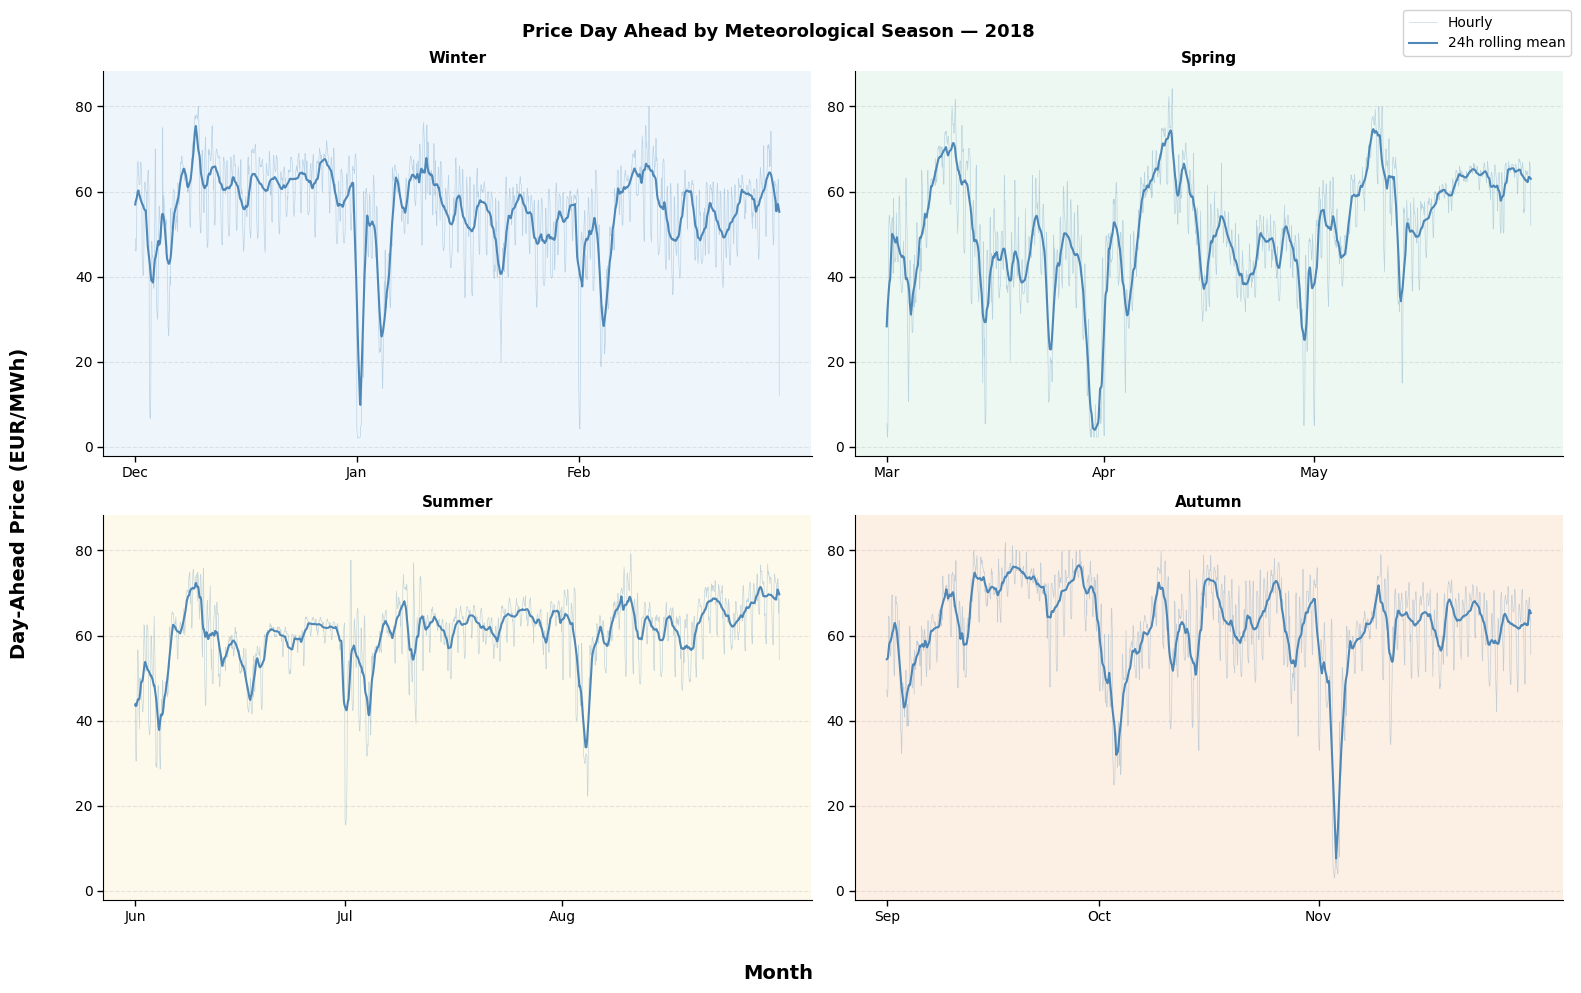

In [36]:
# smoothed
plot_by_season_panel(test_df_filtered, col='price day ahead',
                     rolling_window=24, 
                     ylabel='Day-Ahead Price (EUR/MWh)')

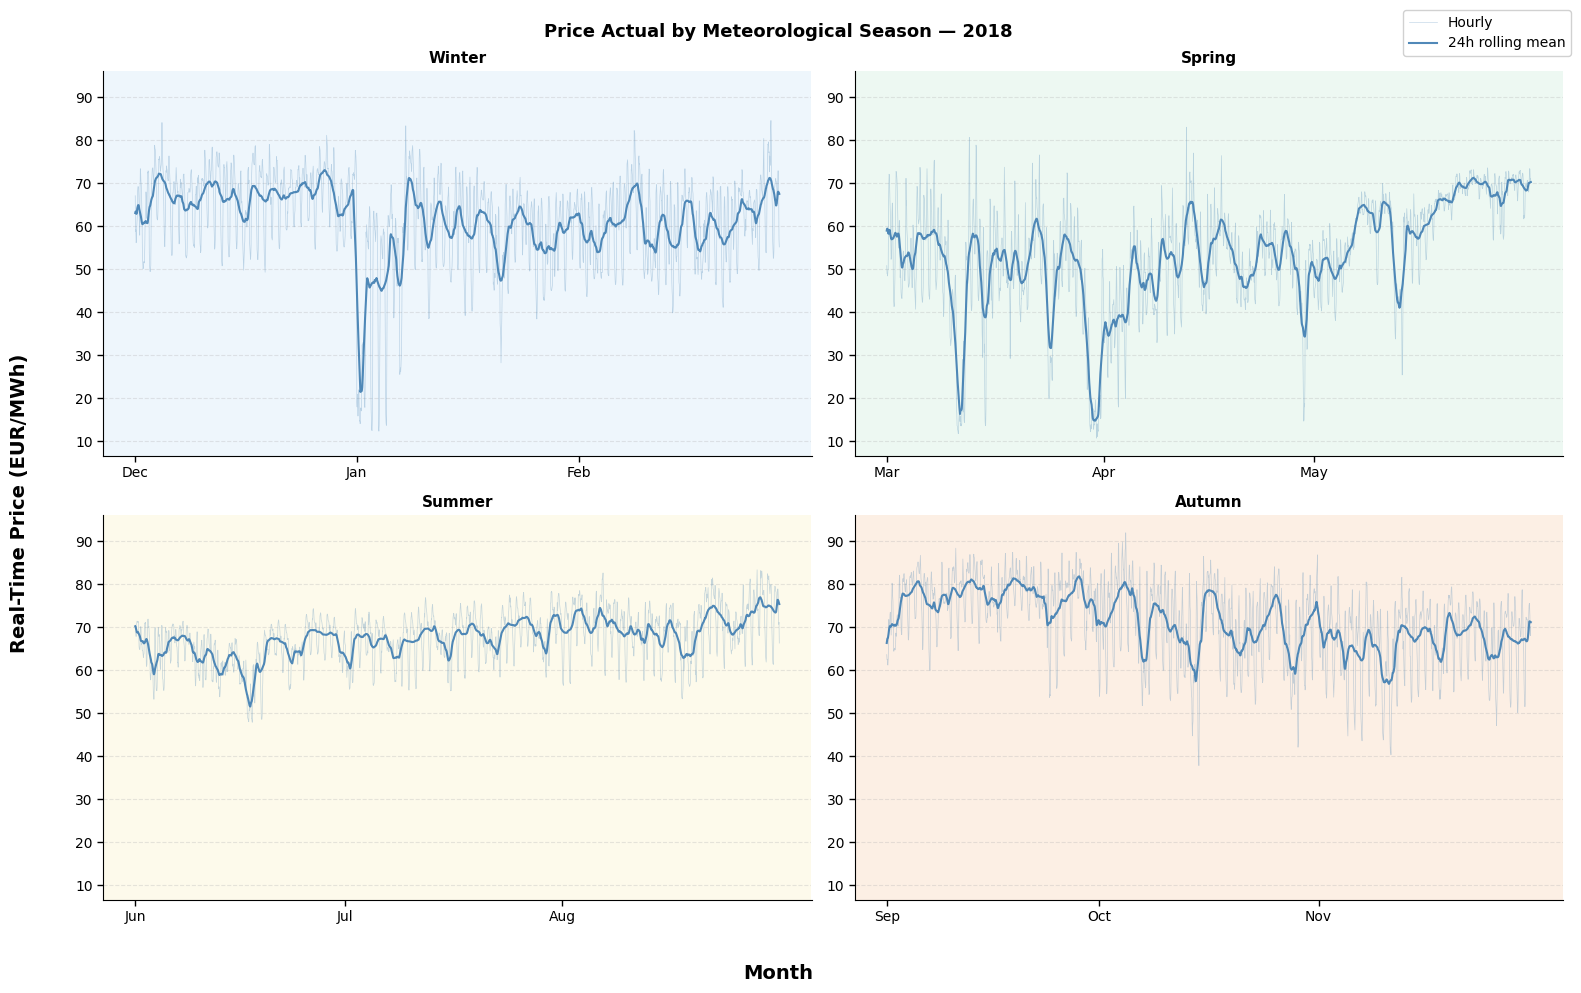

In [37]:
# smoothed
plot_by_season_panel(test_df_filtered, col='price actual',
                     rolling_window=24, 
                     ylabel='Real-Time Price (EUR/MWh)')

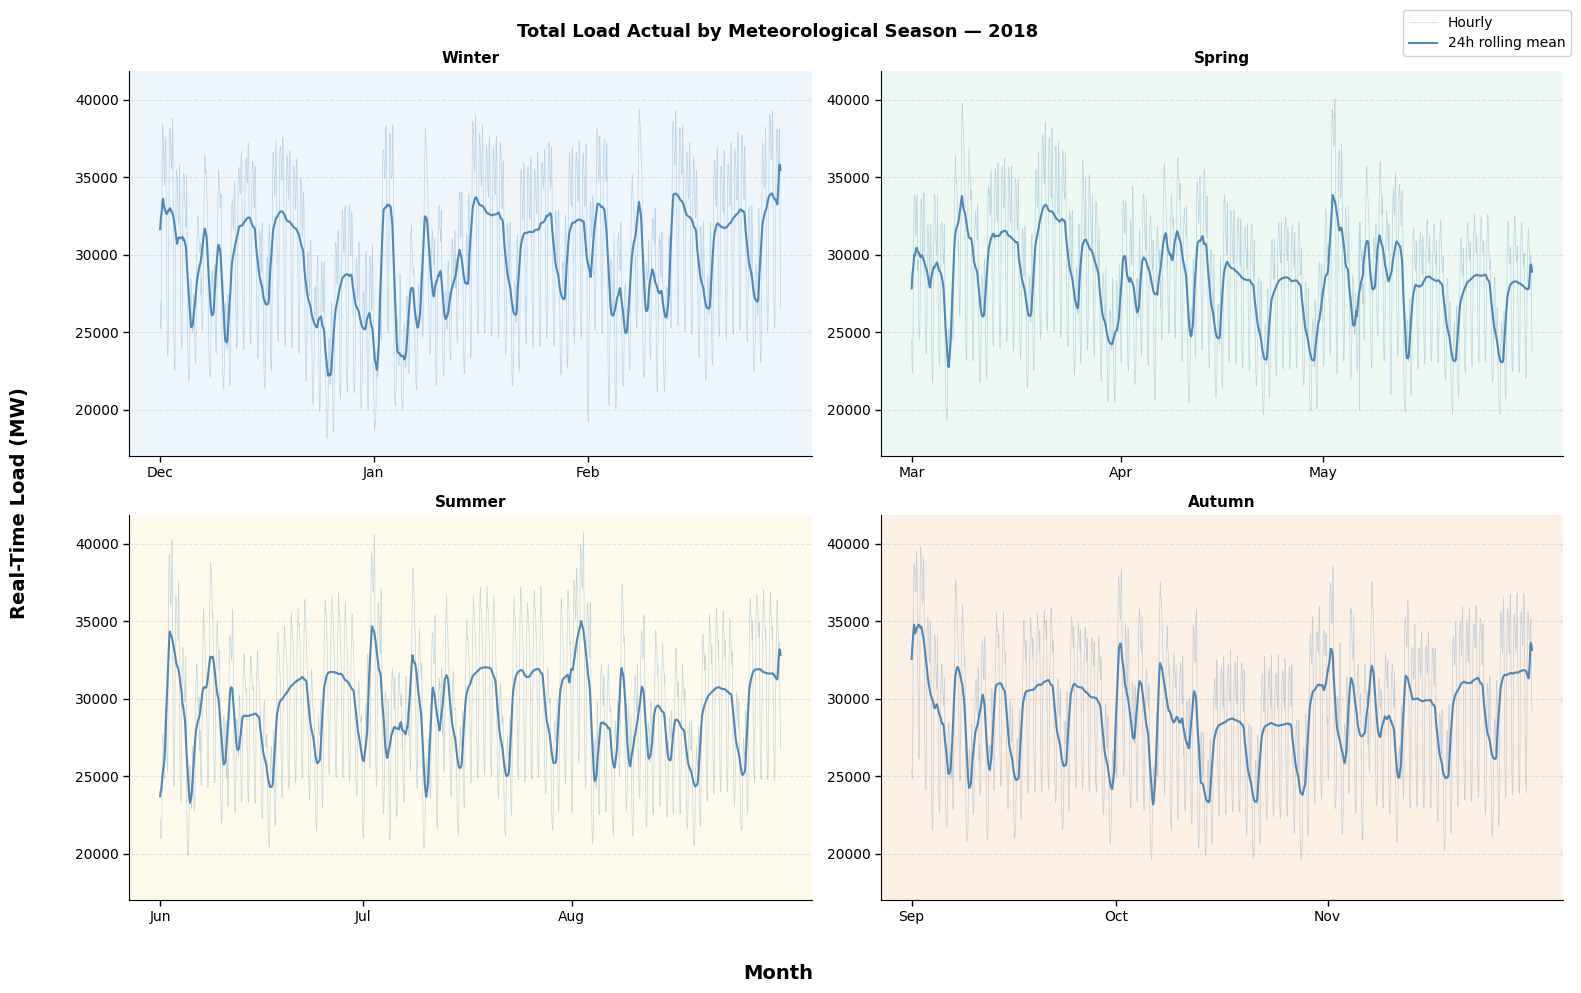

In [38]:
# smoothed
plot_by_season_panel(test_df_filtered, col='total load actual',
                     rolling_window=24, 
                     ylabel='Real-Time Load (MW)')

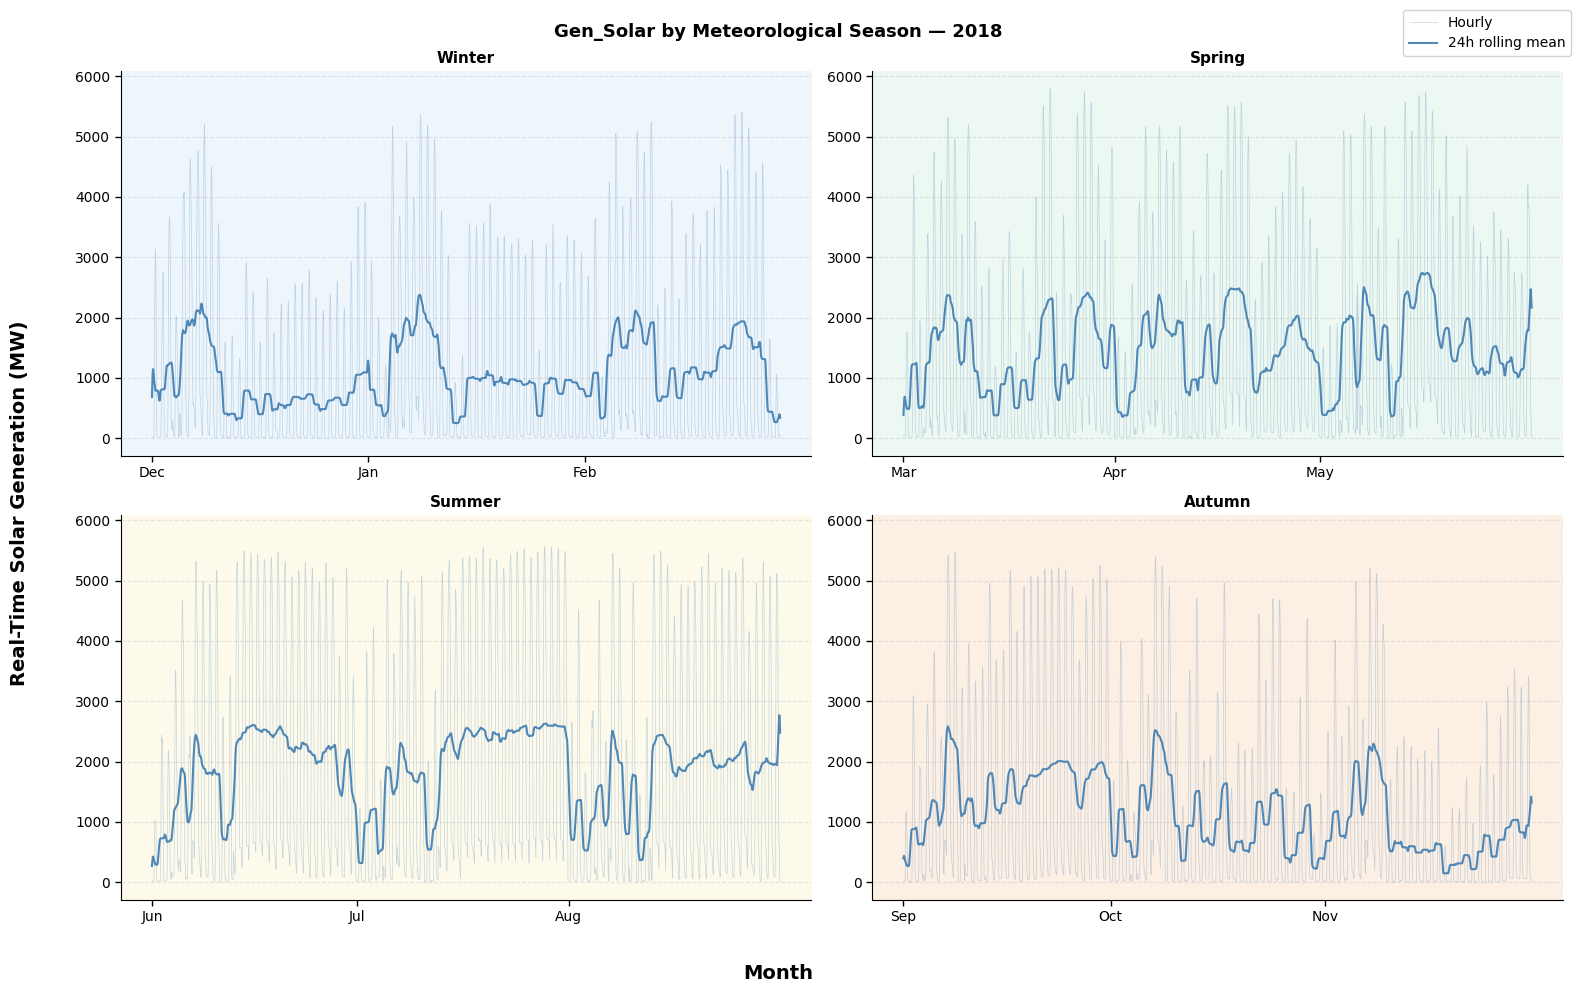

In [39]:
# smoothed
plot_by_season_panel(test_df_filtered, col='gen_solar',
                     rolling_window=24, 
                     ylabel='Real-Time Solar Generation (MW)')

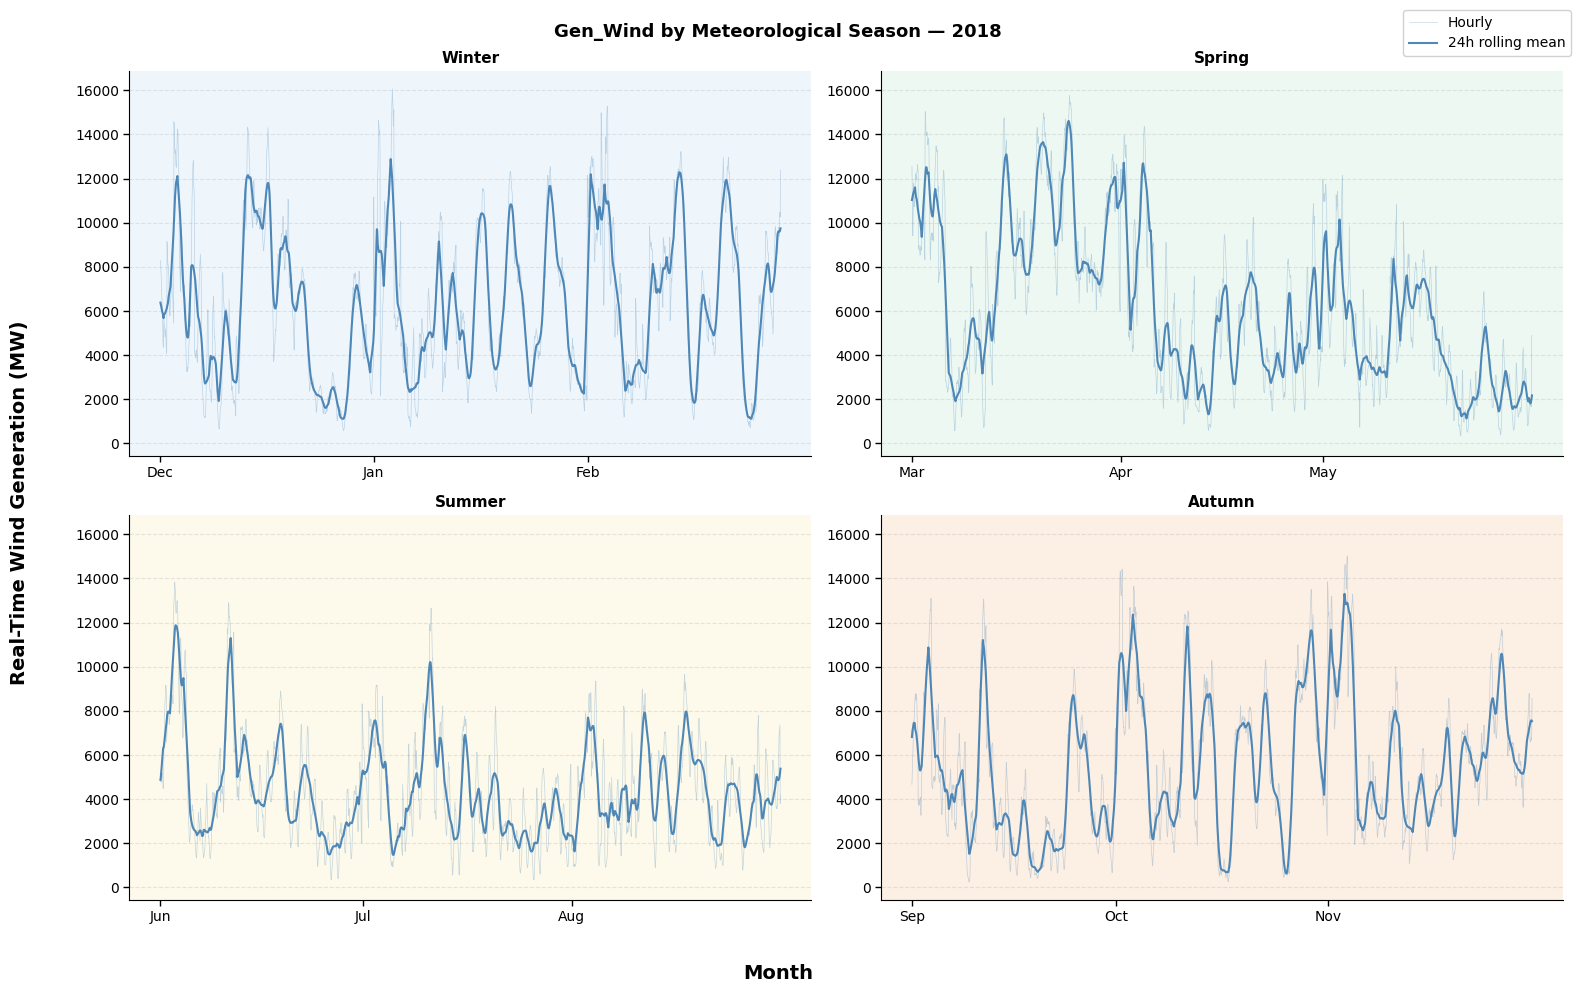

In [40]:
# smoothed
plot_by_season_panel(test_df_filtered, col='gen_wind',
                     rolling_window=24, 
                     ylabel='Real-Time Wind Generation (MW)')

### 2018 avg generation mix 

In [41]:
cols = ['time', 'date', 'hour',
        'gen_solar', 'gen_wind', 'gen_hydro', 'gen_pumped_hydro',
        'gen_fossil', 'gen_nuclear', 'gen_other']

train_df_energy_mix = train_df.copy()[cols]
val_df_energy_mix   = val_df.copy()[cols]
test_df_energy_mix  = test_df.copy()[cols]

# ── Concatenate all splits ────────────────────────────────────────────────────
all_df_energy_mix = pd.concat([
    train_df_energy_mix,
    val_df_energy_mix,
    test_df_energy_mix
], ignore_index=True)

In [42]:
def plot_energy_mix(df, kind='bar', year=None,
                    title=None):
    """
    Plot Spain's energy mix from the dataset generation columns.

    Parameters
    ----------
    df   : DataFrame containing generation columns (all years concatenated)
    kind : 'bar' for horizontal bar chart, 'pie' for pie chart
    year : int or None — filter to a specific year (2015, 2016, 2017, 2018)
           if None, uses all years in df
    """

    # ── Filter by year if specified ───────────────────────────────────────────
    if year is not None:
        times   = pd.to_datetime(df['time'])
        df      = df[times.dt.year == year].copy()
        if len(df) == 0:
            raise ValueError(f"No data found for year {year}")
        year_label = str(year)
    else:
        year_label = '2015–2018'

    # ── Dynamic title ─────────────────────────────────────────────────────────
    if title is None:
        title = f'Spanish Peninsular Energy Mix — {year_label}'

    # ── Map dataset columns to readable labels ────────────────────────────────
    gen_cols = {
        'gen_nuclear'      : 'Nuclear',
        'gen_wind'         : 'Wind',
        'gen_fossil'       : 'Coal & Fossil',
        'gen_hydro'        : 'Hydro',
        'gen_pumped_hydro' : 'Pumped Hydro',
        'gen_solar'        : 'Solar',
        'gen_other'        : 'Other',
    }

    # ── Compute mean generation per source ────────────────────────────────────
    means = {
        label: df[col].mean()
        for col, label in gen_cols.items()
        if col in df.columns
    }

    means  = dict(sorted(means.items(), key=lambda x: x[1], reverse=True))
    labels = list(means.keys())
    values = list(means.values())
    total  = sum(values)
    shares = [v / total * 100 for v in values]

    # ── Color palette ─────────────────────────────────────────────────────────
    colors = {
        'Nuclear'       : '#4a86e8',
        'Wind'          : '#43d692',
        'Coal & Fossil' : '#999999',
        'Hydro'         : '#aed6f1',
        'Pumped Hydro'  : '#6d9eeb',
        'Solar'         : '#fad165',
        'Other'         : '#f0b27a',
    }
    col_list = [colors.get(l, '#cccccc') for l in labels]

    # ── Plot ──────────────────────────────────────────────────────────────────
    if kind == 'bar':
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        bars = ax.barh(labels, shares, color=col_list,
                       edgecolor='white', linewidth=0.5)

        for bar, share in zip(bars, shares):
            ax.text(bar.get_width() + 0.3,
                    bar.get_y() + bar.get_height() / 2,
                    f'{share:.1f}%',
                    va='center', ha='left', fontsize=10)

        ax.set_xlabel('Share of Generation (%)', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.set_xlim(0, max(shares) * 1.2)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    elif kind == 'pie':
        fig, ax = plt.subplots(figsize=(8, 8))

        wedges, texts, autotexts = ax.pie(
            shares,
            labels=labels,
            colors=col_list,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5)
        )
        for text in autotexts:
            text.set_fontsize(9)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=20)

    else:
        raise ValueError(f"kind must be 'bar' or 'pie', got '{kind}'")

    plt.tight_layout()
    plt.show()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f"\n{'Source':<20} {'Avg MW':>10} {'Share':>8}")
    print('─' * 40)
    for label, val, share in zip(labels, values, shares):
        print(f"{label:<20} {val:>10,.1f} {share:>7.1f}%")
    print('─' * 40)
    print(f"{'Total':<20} {total:>10,.1f} {'100.0%':>8}")

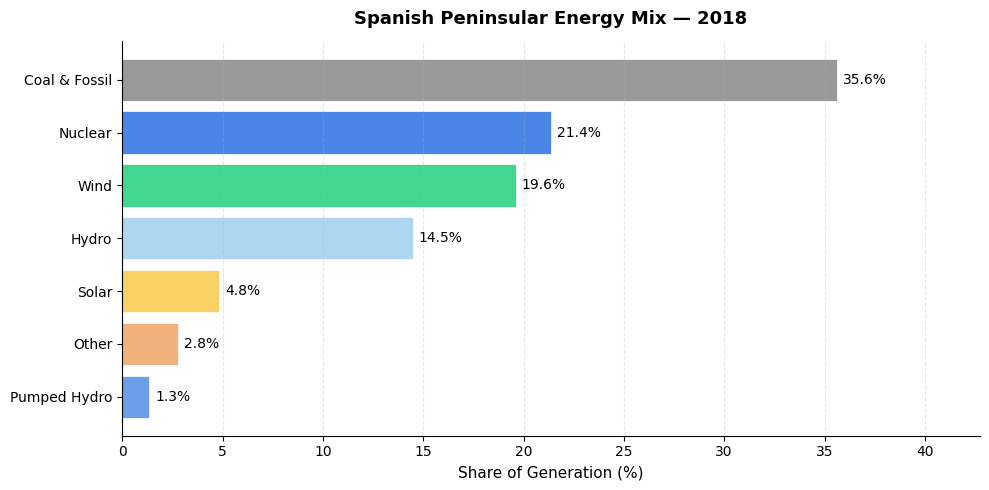


Source                   Avg MW    Share
────────────────────────────────────────
Coal & Fossil          10,146.7    35.6%
Nuclear                 6,082.0    21.4%
Wind                    5,584.6    19.6%
Hydro                   4,124.8    14.5%
Solar                   1,373.0     4.8%
Other                     787.0     2.8%
Pumped Hydro              384.5     1.3%
────────────────────────────────────────
Total                  28,482.6   100.0%


In [43]:
plot_energy_mix(all_df_energy_mix, kind='bar', year=2018)

In [44]:
def plot_energy_mix_by_year(df, kind='grouped_bar',
                             title='Spanish Peninsular Energy Mix — 2015–2018'):
    """
    Compare energy mix across years.

    Parameters
    ----------
    kind : 'grouped_bar'  — side by side bars per source
           'stacked_bar'  — stacked bars per year
           'line'         — line per source across years
    """

    gen_cols = {
        'gen_nuclear'      : 'Nuclear',
        'gen_wind'         : 'Wind',
        'gen_fossil'       : 'Coal & Fossil',
        'gen_hydro'        : 'Hydro',
        'gen_pumped_hydro' : 'Pumped Hydro',
        'gen_solar'        : 'Solar',
        'gen_other'        : 'Other',
    }

    colors = {
        'Nuclear'       : '#4a86e8',
        'Wind'          : '#43d692',
        'Coal & Fossil' : '#999999',
        'Hydro'         : '#aed6f1',
        'Pumped Hydro'  : '#6d9eeb',
        'Solar'         : '#fad165',
        'Other'         : '#f0b27a',
    }

    # ── Compute share per year ────────────────────────────────────────────────
    times = pd.to_datetime(df['time'])
    years = sorted(times.dt.year.unique())

    # shares[year][label] = share %
    year_shares = {}
    for yr in years:
        yr_df  = df[times.dt.year == yr]
        means  = {label: yr_df[col].mean()
                  for col, label in gen_cols.items()
                  if col in df.columns}
        total  = sum(means.values())
        year_shares[yr] = {label: val / total * 100
                           for label, val in means.items()}

    # fix label order by 2018 share descending
    label_order = sorted(
        gen_cols.values(),
        key=lambda l: year_shares[years[-1]][l],
        reverse=True
    )

    # ── Grouped bar ───────────────────────────────────────────────────────────
    if kind == 'grouped_bar':
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        n_years  = len(years)
        n_labels = len(label_order)
        bar_h    = 0.8 / n_years
        y_pos    = np.arange(n_labels)

        for i, yr in enumerate(years):
            offsets = y_pos - 0.4 + i * bar_h + bar_h / 2
            shares  = [year_shares[yr][l] for l in label_order]
            bars    = ax.barh(offsets, shares, height=bar_h * 0.9,
                              label=str(yr), alpha=0.85,
                              edgecolor='white', linewidth=0.4)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(label_order, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel('Share of Generation (%)', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    # ── Stacked bar ───────────────────────────────────────────────────────────
    elif kind == 'stacked_bar':
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        x      = np.arange(len(years))
        bottom = np.zeros(len(years))

        for label in label_order:
            shares = [year_shares[yr][label] for yr in years]
            bars   = ax.bar(x, shares, bottom=bottom,
                            label=label, color=colors.get(label, '#cccccc'),
                            edgecolor='white', linewidth=0.5)

            # label inside bar if big enough
            for j, (bar, share) in enumerate(zip(bars, shares)):
                if share > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bottom[j] + share / 2,
                            f'{share:.1f}%',
                            ha='center', va='center',
                            fontsize=8, color='white', fontweight='bold')
            bottom += np.array(shares)

        ax.set_xticks(x)
        ax.set_xticklabels([str(yr) for yr in years], fontsize=11)
        ax.set_ylabel('Share of Generation (%)', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # ── Flip legend to match stack order ──────────────────────────────────
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1],
                  bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    # ── Line chart ────────────────────────────────────────────────────────────
    elif kind == 'line':
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for label in label_order:
            shares = [year_shares[yr][label] for yr in years]
            ax.plot(years, shares, marker='o', linewidth=2,
                    label=label, color=colors.get(label, '#cccccc'))

            # label at end of line
            ax.text(years[-1] + 0.05, shares[-1],
                    f'{label} ({shares[-1]:.1f}%)',
                    va='center', fontsize=8)

        ax.set_xticks(years)
        ax.set_xlabel('Year', fontsize=11)
        ax.set_ylabel('Share of Generation (%)', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.set_xlim(years[0] - 0.2, years[-1] + 1.5)
        ax.grid(alpha=0.3, linestyle='--')

    else:
        raise ValueError(f"kind must be 'grouped_bar', 'stacked_bar' or 'line'")

    # fig.text(0.99, 0.01,
    #          'Source: Dataset — energy_weather_merged.csv',
    #          ha='right', va='bottom', fontsize=8, color='grey', style='italic')

    plt.tight_layout()
    plt.show()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f"\n{'Source':<20}", end='')
    for yr in years:
        print(f"{yr:>10}", end='')
    print()
    print('─' * (20 + 10 * len(years)))
    for label in label_order:
        print(f"{label:<20}", end='')
        for yr in years:
            print(f"{year_shares[yr][label]:>9.1f}%", end='')
        print()

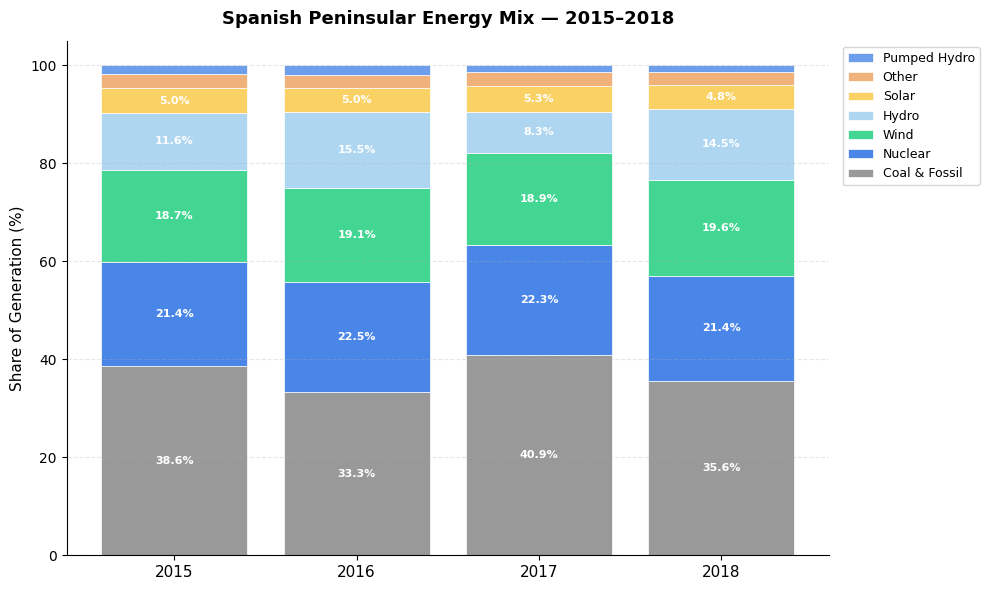


Source                    2015      2016      2017      2018
────────────────────────────────────────────────────────────
Coal & Fossil            38.6%     33.3%     40.9%     35.6%
Nuclear                  21.4%     22.5%     22.3%     21.4%
Wind                     18.7%     19.1%     18.9%     19.6%
Hydro                    11.6%     15.5%      8.3%     14.5%
Solar                     5.0%      5.0%      5.3%      4.8%
Other                     2.9%      2.7%      2.8%      2.8%
Pumped Hydro              1.8%      2.0%      1.5%      1.3%


In [45]:
plot_energy_mix_by_year(all_df_energy_mix, kind='stacked_bar')


In [46]:
# plot_energy_mix_by_year(all_df_energy_mix, kind='grouped_bar')

In [47]:
# plot_energy_mix_by_year(all_df_energy_mix, kind='line')

### Energy Mix (in terms of `Nameplate Generation Capacity`)

In [48]:
def plot_energy_mix_ree(kind='bar',
                        title='Spanish Peninsular Energy Mix — 2018 (REE)'):

    # ── REE 2018 figures mapped to your dataset buckets ──────────────────────
    # Source: Red Eléctrica de España, Spanish Electricity System Report 2018
    #
    # gen_nuclear      → Nuclear (21.5%)
    # gen_wind         → Wind (19.8%)
    # gen_fossil       → Coal (14.1%) + Combined Cycle (10.7%) = 24.8%
    # gen_hydro        → Hydro (13.8%)
    # gen_pumped_hydro → Pumped Storage (0.8%)
    # gen_solar        → Solar PV (3.0%) + Solar Thermal (1.8%) = 4.8%
    # gen_other        → Cogeneration (11.9%) + Other Renewables (1.4%)
    #                    + Non-ren. Waste (0.9%) + Renewable Waste (0.3%) = 14.5%

    bucketed_mix = {
        'Nuclear'         : 21.5,                    # gen_nuclear
        'Wind'            : 19.8,                    # gen_wind
        'Coal & Fossil'   : 14.1 + 10.7,            # gen_fossil
        'Hydro'           : 13.8,                    # gen_hydro
        'Solar'           :  3.0 + 1.8,             # gen_solar
        'Other'           : 11.9 + 1.4 + 0.9 + 0.3, # gen_other
        'Pumped Hydro'    :  0.8,                    # gen_pumped_hydro
    }

    # sort descending
    bucketed_mix = dict(sorted(bucketed_mix.items(),
                               key=lambda x: x[1], reverse=True))
    labels  = list(bucketed_mix.keys())
    shares  = list(bucketed_mix.values())

    colors = {
        'Nuclear'       : '#4a86e8',
        'Wind'          : '#43d692',
        'Coal & Fossil' : '#999999',
        'Hydro'         : '#aed6f1',
        'Solar'         : '#fad165',
        'Other'         : '#f0b27a',
        'Pumped Hydro'  : '#6d9eeb',
    }
    col_list = [colors.get(l, '#cccccc') for l in labels]

    if kind == 'bar':
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        bars = ax.barh(labels, shares, color=col_list,
                       edgecolor='white', linewidth=0.5)

        for bar, share in zip(bars, shares):
            ax.text(bar.get_width() + 0.3,
                    bar.get_y() + bar.get_height() / 2,
                    f'{share:.1f}%',
                    va='center', ha='left', fontsize=10)

        ax.set_xlabel('Share of Generation (%)', fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.set_xlim(0, max(shares) * 1.25)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    elif kind == 'pie':
        fig, ax = plt.subplots(figsize=(8, 8))

        wedges, texts, autotexts = ax.pie(
            shares,
            labels=labels,
            colors=col_list,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5)
        )
        for text in autotexts:
            text.set_fontsize(9)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=20)

    else:
        raise ValueError(f"kind must be 'bar' or 'pie', got '{kind}'")

    fig.text(0.99, -0.01,
             'Source: Red Eléctrica de España, Spanish Electricity System Report 2018',
             ha='right', va='bottom', fontsize=8, color='grey', style='italic')

    plt.tight_layout()
    plt.show()

    # ── Print table with bucket mapping ──────────────────────────────────────
    print(f"\n{'Dataset Column':<20} {'REE Categories':<45} {'Share':>8}")
    print('─' * 75)
    mappings = {
        'gen_nuclear'     : ('Nuclear',       'Nuclear'),
        'gen_wind'        : ('Wind',          'Wind'),
        'gen_fossil'      : ('Coal & Fossil', 'Coal (14.1%) + Combined Cycle (10.7%)'),
        'gen_hydro'       : ('Hydro',         'Hydro'),
        'gen_solar'       : ('Solar',         'Solar PV (3.0%) + Solar Thermal (1.8%)'),
        'gen_other'       : ('Other',         'Cogeneration + Other Ren. + Waste'),
        'gen_pumped_hydro': ('Pumped Hydro',  'Pumped Storage'),
    }
    for col, (bucket, ree_cats) in mappings.items():
        share = bucketed_mix[bucket]
        print(f"{col:<20} {ree_cats:<45} {share:>7.1f}%")
    print('─' * 75)
    print(f"{'Total':<65} {sum(shares):>7.1f}%")

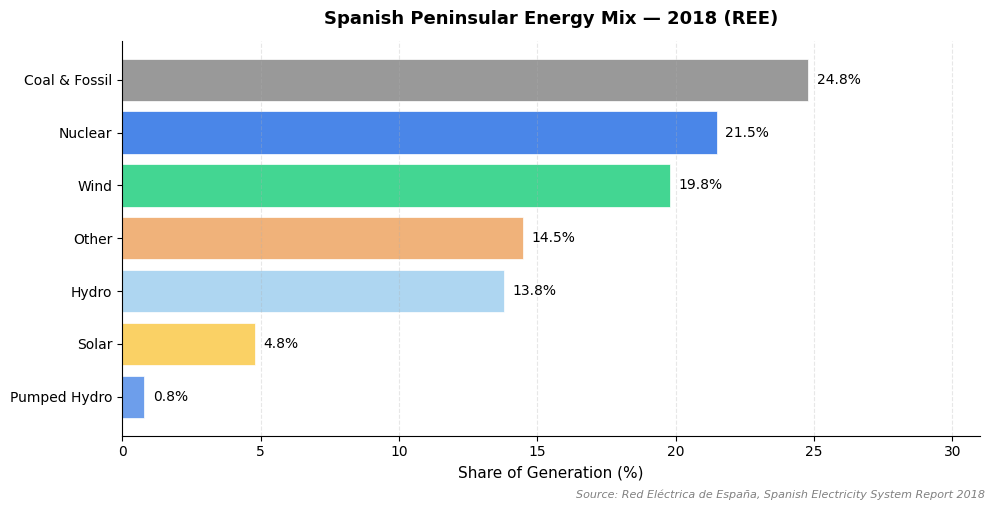


Dataset Column       REE Categories                                   Share
───────────────────────────────────────────────────────────────────────────
gen_nuclear          Nuclear                                          21.5%
gen_wind             Wind                                             19.8%
gen_fossil           Coal (14.1%) + Combined Cycle (10.7%)            24.8%
gen_hydro            Hydro                                            13.8%
gen_solar            Solar PV (3.0%) + Solar Thermal (1.8%)            4.8%
gen_other            Cogeneration + Other Ren. + Waste                14.5%
gen_pumped_hydro     Pumped Storage                                    0.8%
───────────────────────────────────────────────────────────────────────────
Total                                                               100.0%


In [49]:
plot_energy_mix_ree(kind='bar')